In [1]:
import pandas as pd

In [2]:
import os
os.getcwd()

'C:\\Users\\valak\\Favorites\\Downloads\\transaction_prediction'

In [3]:
os.listdir()

['.ipynb_checkpoints', 'customer_transaction_prediction.ipynb', 'train(1).csv']

In [4]:
data = pd.read_csv("C:/Users/valak/Downloads/transaction_prediction/train(1).csv")

In [9]:
data.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [10]:
data.shape

(200000, 202)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [14]:
data.isnull().sum().sum()

0

In [17]:
data["target"].value_counts()

target
0    179902
1     20098
Name: count, dtype: int64

## EDA 

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

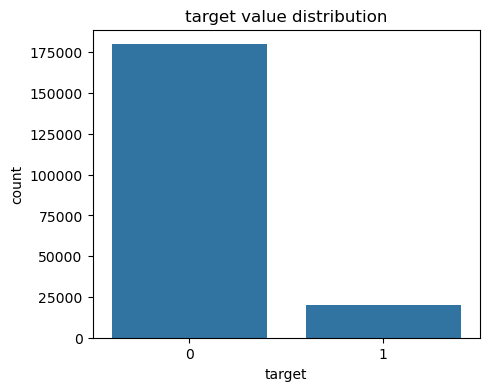

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x='target',data=data)
plt.title("target value distribution")
plt.show()

In [20]:
data.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [22]:
data.select_dtypes(include='number').var().sort_values().head(10)

var_68     0.000052
var_91     0.023299
var_108    0.029272
var_103    0.034232
var_12     0.036123
var_148    0.039678
var_161    0.047497
var_71     0.071127
var_25     0.081530
target     0.090392
dtype: float64

## random features

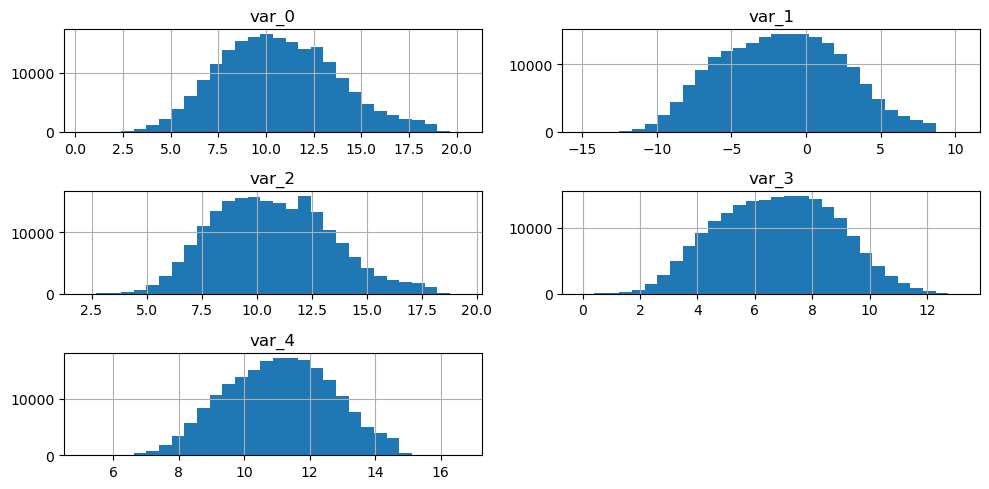

In [23]:
features = ['var_0','var_1','var_2','var_3','var_4']
data[features].hist(figsize=(10,5),bins=30)
plt.tight_layout()
plt.show()

## data preparation $ feature scaling

In [11]:
data=data.drop(columns=['ID_code'])

In [6]:
x=data.drop(columns=['target'])
y=data['target']

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [16]:
#drop id_codecolumn again because getting error for value error

In [13]:
if'ID_code' in x_train.columns:
    x_train=x_train.drop('ID_code',axis=1)
    x_test=x_test.drop('ID_code',axis=1)

In [32]:
#verify shapes
print("training set shape: ",x_train_scaled.shape)
print("testing set shape: ",x_test_scaled.shape)

training set shape:  (160000, 200)
testing set shape:  (40000, 200)


## model building

In [14]:
from sklearn.linear_model import LogisticRegression
#creating the logistic regrestion model
model=LogisticRegression(max_iter=1000,random_state=42)


#train the model
model.fit(x_train,y_train)

C:\Users\valak\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#prediction on the test set
y_pred=model.predict(x_test)

In [21]:
#evaluate model
from sklearn.metrics import accuracy_score,classification_report

print(" * Accuracy:",accuracy_score(y_test,y_pred))
print("\n * classification report:\n",classification_report(y_test,y_pred))

 * Accuracy: 0.91315

 * classification report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95     35980
           1       0.68      0.26      0.37      4020

    accuracy                           0.91     40000
   macro avg       0.80      0.62      0.66     40000
weighted avg       0.90      0.91      0.90     40000



## model improvement

In [22]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1,class_weight='balanced')

In [24]:
#train the model
rf_model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [25]:
y_pred_rf=rf_model.predict(x_test)

In [27]:
from sklearn.metrics import accuracy_score,classification_report

print(" * random forest accuracy:",accuracy_score(y_test,y_pred_rf))
print("\n * classification report:\n",classification_report(y_test,y_pred_rf))

 * random forest accuracy: 0.8995

 * classification report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95     35980
           1       0.00      0.00      0.00      4020

    accuracy                           0.90     40000
   macro avg       0.45      0.50      0.47     40000
weighted avg       0.81      0.90      0.85     40000



C:\Users\valak\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\valak\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\valak\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## create new .csv file for power bi

In [15]:
df={'model':['Logistic Regression','Random Forest'],
     'Accuracy':[0.91,0.90],
     'precision':[0.90,0.81],
    'Recall':[0.91,0.90],
    'F1_score':[0.90,0.85]
   }
result_df=pd.DataFrame(df)
result_df.to_csv('model_results.csv',index=False)
print("model_result.csv created")

model_result.csv created
